# Visualiser l’évolution des métriques des modèles (TrAIn.me)

Notebook prêt à l’emploi pour lire le CSV des métriques versionnées et tracer l’évolution par version et par modèle.
Il tente d’importer `visualize_evolution_metrics.py` si présent ; sinon, des fonctions locales sont utilisées.

In [16]:
# === Configuration des chemins ===
from pathlib import Path

CSV_PATH = Path(r"C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\logs\evolutions_metrics.csv")
if not CSV_PATH.exists():
    alt = Path('/mnt/data/evolutions_metrics.csv')
    if alt.exists():
        CSV_PATH = alt
VIZ_MODULE_PATH = Path(r"C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\logs\visualize_model_evolution.py")
print('CSV :', CSV_PATH)
print('Module utils :', VIZ_MODULE_PATH, '(existe ?', VIZ_MODULE_PATH.exists(), ')')
FIG_DIR = Path('./figures_evolutions'); FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Figures →', FIG_DIR.resolve())

CSV : C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\logs\evolutions_metrics.csv
Module utils : C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\logs\visualize_model_evolution.py (existe ? False )
Figures → C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\logs\figures_evolutions


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib.util, re
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

def _try_import_visual_module(path: Path):
    if path.exists():
        spec = importlib.util.spec_from_file_location('viz_mod', str(path))
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)  # type: ignore
        return mod
    return None

viz_mod = _try_import_visual_module(VIZ_MODULE_PATH)
print('Module utils chargé ? →', bool(viz_mod))

Module utils chargé ? → False


In [18]:
# === Chargement & parsing spécifique de evolutions_metrics.csv ===
import pandas as pd
import numpy as np
import re

raw = pd.read_csv(CSV_PATH)
print("RAW shape:", raw.shape)
display(raw)

# Le fichier est structuré en blocs :
# ligne 0 : nom du PDF (version)
# ligne 1 : features utilisées
# ligne 2 : 'Modèle', 'MAE', 'RMSE', 'R²'
# lignes 3..5 : données (0/1/2 + nom du modèle + MAE/RMSE/R²)
# ligne 6 : vide
# puis même pattern pour v2.1, etc.

blocks = []
for idx, val in raw["Unnamed: 1"].items():
    if str(val).strip() == "Modèle":
        header_idx = idx
        version_idx = idx - 2
        feat_idx = idx - 1
        blocks.append((version_idx, feat_idx, header_idx))

print("Blocs détectés (version_idx, features_idx, header_idx) :", blocks)

rows = []
for version_idx, feat_idx, header_idx in blocks:
    version = str(raw.loc[version_idx, "Unnamed: 0"]).strip()
    features = str(raw.loc[feat_idx, "Unnamed: 0"]).strip()

    # lignes de données juste après le header, jusqu'à la prochaine ligne vide en Unnamed: 1
    i = header_idx + 1
    while i < len(raw) and pd.notna(raw.loc[i, "Unnamed: 1"]):
        model_id = raw.loc[i, "Unnamed: 1"]

        # Nom du modèle = concat des colonnes 2 et 3 (Random + Forest, Gradient + Boosting, ...)
        part1 = str(raw.loc[i, "Unnamed: 2"]).strip()
        part2 = str(raw.loc[i, "Unnamed: 3"]).strip()        
        model_name = " ".join(
            [p for p in [part1, part2] if p and p.lower() != "nan"]
        )
        print(model_name)

        mae = pd.to_numeric(raw.loc[i, "Unnamed: 4"], errors="coerce")
        rmse = pd.to_numeric(raw.loc[i, "Unnamed: 5"], errors="coerce")
        r2 = pd.to_numeric(raw.loc[i, "Unnamed: 6"], errors="coerce")

        rows.append(
            {
                "version": version,
                "features": features,
                "model_id": model_id,
                "model": model_name,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2,
            }
        )
        i += 1

df = pd.DataFrame(rows)
print("DF tidy :")
display(df)

# Tri sémantique des versions : preprocessing_life_style_data_v2.0.pdf, v2.1, etc.
def _semver_key(v):
    if pd.isna(v):
        return ()
    s = str(v)
    # on cherche un motif du type v2.1 ou 2.1
    m = re.search(r"(?:v|V)?(\d+(?:\.\d+)*)", s)
    if not m:
        return (s,)
    try:
        return tuple(int(x) for x in m.group(1).split("."))
    except Exception:
        return (s,)

df = df.sort_values("version", key=lambda s: s.map(_semver_key)).reset_index(drop=True)

# Index numérique de version pour l'axe des x
df["_version_idx"] = pd.factorize(df["version"])[0] + 1

display(df)


RAW shape: (162, 7)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,"v1,6 (sans features selection)",NaN,NaN,NaN,NaN,NaN,NaN
1,ALL,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Modèle,MAE,RMSE,R²,NaN,NaN
3,NaN,0,Random,Forest,0.001546,0.005405,0.999970
4,NaN,1,Gradient,Boosting,0.014526,0.019516,0.999615
...,...,...,...,...,...,...,...
157,NaN,Modèle,MAE,RMSE,R²,NaN,NaN
158,NaN,0,Random,Forest,0.148544,0.243314,0.940173
159,NaN,1,Bagging,Regressor,0.148680,0.243490,0.940086
160,NaN,2,Gradient,Boosting,0.379663,0.480329,0.766845


Blocs détectés (version_idx, features_idx, header_idx) : [(0, 1, 2), (7, 8, 9), (14, 15, 16), (21, 22, 23), (28, 29, 30), (35, 36, 37), (42, 43, 44), (49, 50, 51), (56, 57, 58), (63, 64, 65), (70, 71, 72), (77, 78, 79), (84, 85, 86), (91, 92, 93), (99, 100, 101), (107, 108, 109), (115, 116, 117), (123, 124, 125), (131, 132, 133), (139, 140, 141), (147, 148, 149), (155, 156, 157)]
Random Forest
Gradient Boosting
Régression Linéaire
Random Forest
Gradient Boosting
Régression Linéaire
Random Forest
Gradient Boosting
Régression Linéaire
Random Forest
Gradient Boosting
Régression Linéaire
Random Forest
Gradient Boosting
Régression Linéaire
Gradient Boosting
Régression Linéaire
Random Forest
Gradient Boosting
Régression Linéaire
Random Forest
Gradient Boosting
Régression Linéaire
Random Forest
Gradient Boosting
Random Forest
Régression Linéaire
Gradient Boosting
Random Forest
Régression Linéaire
Random Forest
Gradient Boosting
Régression Linéaire
Random Forest
Gradient Boosting
Régression Li

,version,features,model_id,model,MAE,RMSE,R2
0,"v1,6 (sans features selection)",ALL,0,Random Forest,0.001546,0.005405,0.999970
1,"v1,6 (sans features selection)",ALL,1,Gradient Boosting,0.014526,0.019516,0.999615
2,"v1,6 (sans features selection)",ALL,2,Régression Linéaire,0.103931,0.135711,0.981373
3,V2.0 (2 labels > Age + Weight),"""Age"", ""Weight (kg)""",0,Random Forest,0.588302,0.759869,0.416494
4,V2.0 (2 labels > Age + Weight),"""Age"", ""Weight (kg)""",1,Gradient Boosting,0.676781,0.841083,0.285100
...,...,...,...,...,...,...,...
70,V3.2 (suppression vague 2),"""Age"", ""Weight (kg)"", ""Gender"", ""Experience_Le...",3,Régression Linéaire,1.123566,1.414834,-1.022920
71,V3.3 (suppression vague 3),"""Age"", ""Weight (kg)"", ""Gender"", ""Workout_Frequ...",0,Random Forest,0.148544,0.243314,0.940173
72,V3.3 (suppression vague 3),"""Age"", ""Weight (kg)"", ""Gender"", ""Workout_Frequ...",1,Bagging Regressor,0.148680,0.243490,0.940086
73,V3.3 (suppression vague 3),"""Age"", ""Weight (kg)"", ""Gender"", ""Workout_Frequ...",2,Gradient Boosting,0.379663,0.480329,0.766845


,version,features,model_id,model,MAE,RMSE,R2,_version_idx
0,"v1,6 (sans features selection)",ALL,0,Random Forest,0.001546,0.005405,0.999970,1
1,"v1,6 (sans features selection)",ALL,1,Gradient Boosting,0.014526,0.019516,0.999615,1
2,"v1,6 (sans features selection)",ALL,2,Régression Linéaire,0.103931,0.135711,0.981373,1
3,V2.0 (2 labels > Age + Weight),"""Age"", ""Weight (kg)""",0,Random Forest,0.588302,0.759869,0.416494,2
4,V2.0 (2 labels > Age + Weight),"""Age"", ""Weight (kg)""",1,Gradient Boosting,0.676781,0.841083,0.285100,2
...,...,...,...,...,...,...,...,...
70,V3.2 (suppression vague 2),"""Age"", ""Weight (kg)"", ""Gender"", ""Experience_Le...",3,Régression Linéaire,1.123566,1.414834,-1.022920,21
71,V3.3 (suppression vague 3),"""Age"", ""Weight (kg)"", ""Gender"", ""Workout_Frequ...",2,Gradient Boosting,0.379663,0.480329,0.766845,22
72,V3.3 (suppression vague 3),"""Age"", ""Weight (kg)"", ""Gender"", ""Workout_Frequ...",0,Random Forest,0.148544,0.243314,0.940173,22
73,V3.3 (suppression vague 3),"""Age"", ""Weight (kg)"", ""Gender"", ""Workout_Frequ...",1,Bagging Regressor,0.148680,0.243490,0.940086,22


In [19]:
# === Fonctions locales (fallback) ===
def plot_metric_over_versions(df, metric='MAE', group_col='model', title=None, savepath=None):
    data = df.copy()
    if group_col not in data.columns:
        group_col = 'features' if 'features' in data.columns else None
    groups = ['all'] if group_col is None else sorted(data[group_col].fillna('all').unique())
    fig, ax = plt.subplots()
    for g in groups:
        sub = data if g == 'all' or group_col is None else data[data[group_col] == g]
        ax.plot(sub['_version_idx'], sub[metric], marker='o', label=str(g))
    ax.set_xlabel('Versions (index)')
    ax.set_xticks(data['_version_idx'].unique())
    ax.set_xticklabels(data['version'].unique(), rotation=45, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(title or f'Evolution {metric} par version')
    if len(groups) > 1:
        ax.legend()
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150)
    plt.show()

def plot_bar_by_version(df, metrics=("MAE","RMSE","R2"), agg="mean", savepath=None):
    """
    Barres groupées par version, après agrégation des métriques
    sur tous les modèles d'une même version.

    agg : 'mean', 'min', 'max'...
    """
    data = df.copy()

    # Ne garder que les métriques existantes
    metrics = [m for m in metrics if m in data.columns]
    if not metrics:
        print("Aucune métrique à tracer.")
        return

    if "version" not in data.columns:
        print("Pas de colonne 'version' dans le DataFrame.")
        return

    # Agrégation par version (par défaut: moyenne)
    grouped = data.groupby("version")[metrics].agg(agg)
    versions = grouped.index.to_list()

    x = np.arange(len(versions))
    width = 0.8 / len(metrics)  # largeur totale ≈ 0.8

    fig, ax = plt.subplots()
    for i, m in enumerate(metrics):
        vals = grouped[m].values  # même taille que x
        ax.bar(
            x + i * width - 0.4 + width / 2,
            vals,
            width,
            label=m,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(versions, rotation=45, ha="right")
    ax.set_title(f"Comparaison des métriques par version (agg={agg})")
    ax.set_ylabel("Valeur")
    ax.legend()
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150)
    plt.show()


def plot_delta_vs_prev(df, metric='MAE', savepath=None):
    data = df.sort_values('_version_idx').copy()
    data['_delta'] = data[metric].diff()
    fig, ax = plt.subplots()
    ax.plot(data['_version_idx'], data['_delta'], marker='o')
    ax.set_xticks(data['_version_idx'])
    ax.set_xticklabels(data['version'], rotation=45, ha='right')
    ax.set_xlabel('Version')
    ax.set_ylabel(f'Δ {metric} (vs précédente)')
    ax.set_title(f'Delta {metric} entre versions')
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150)
    plt.show()

→ MAE


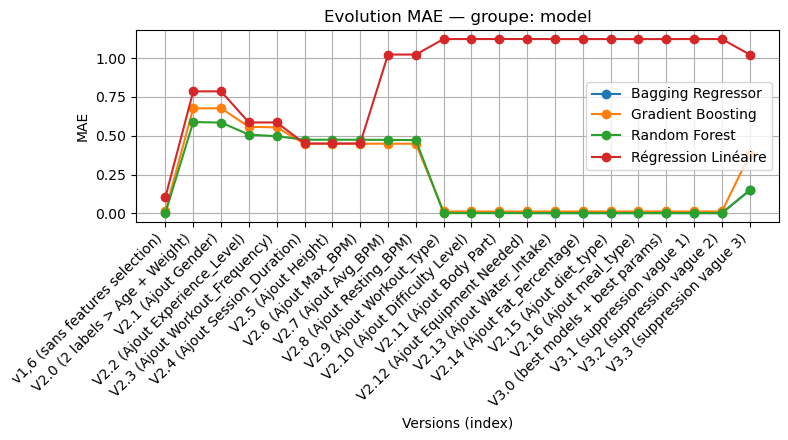

→ RMSE


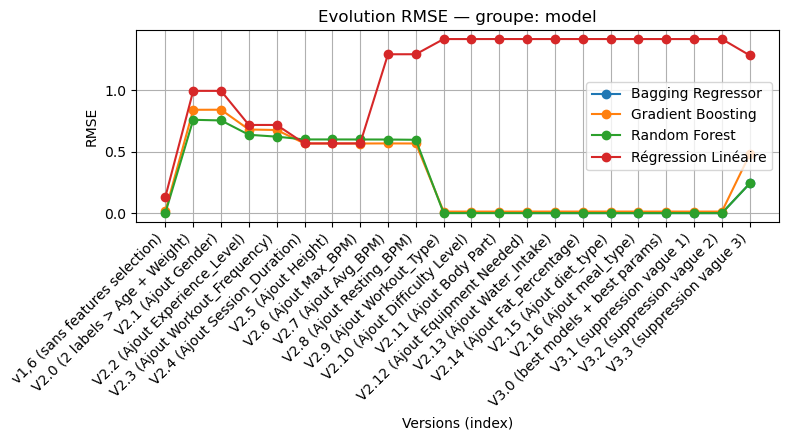

→ R2


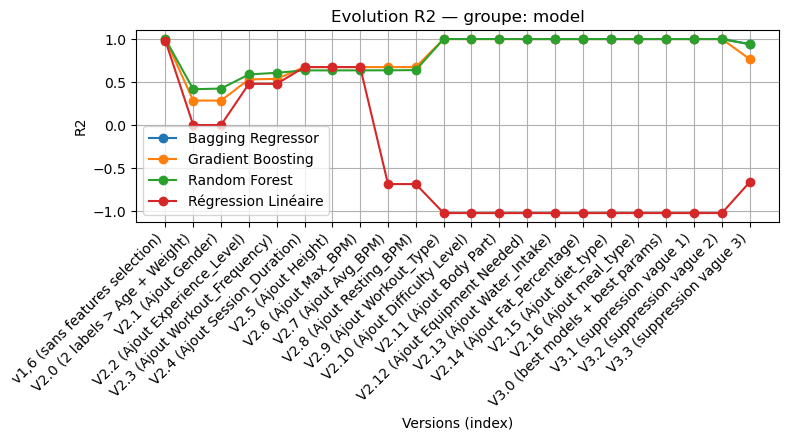

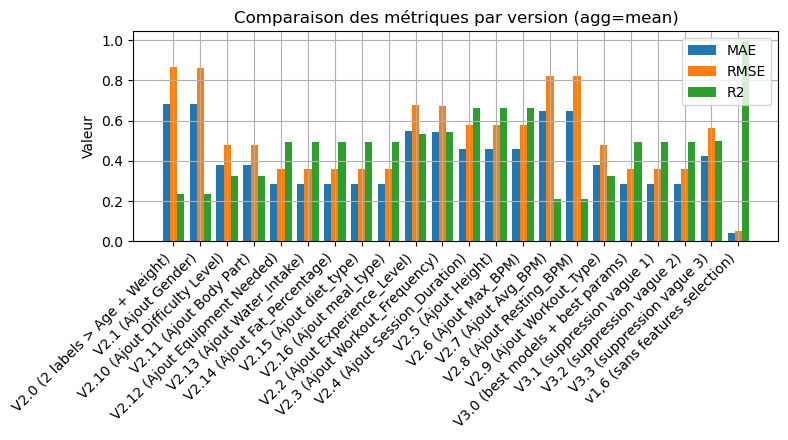

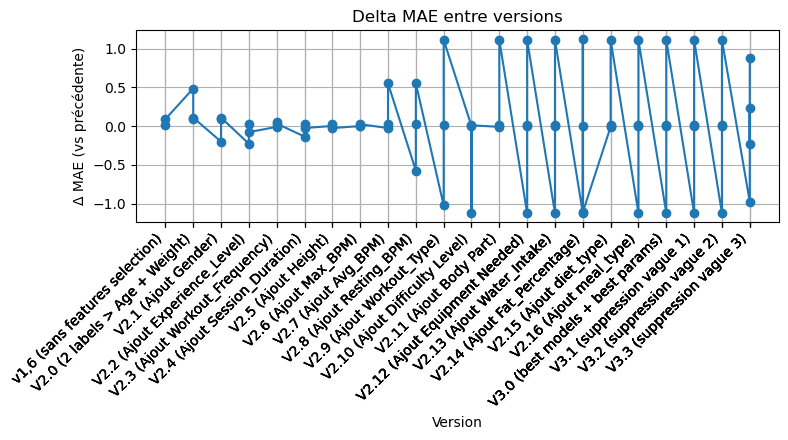

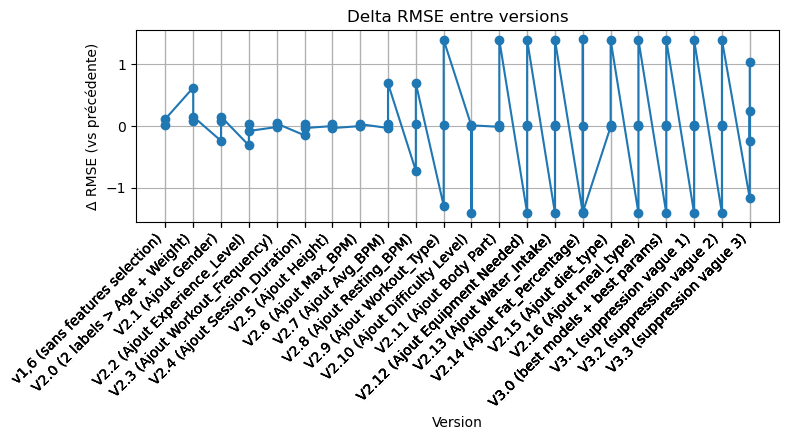

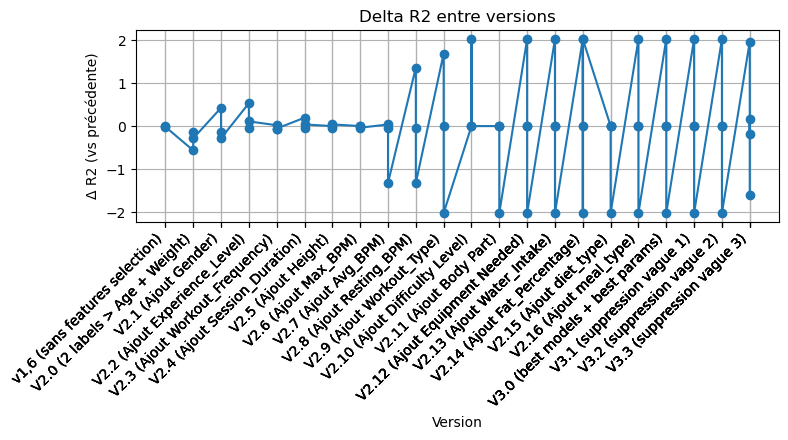

In [20]:
# === Sélection des fonctions (module externe si dispo) ===
plot_metric = getattr(viz_mod, 'plot_metric_over_versions', None) or plot_metric_over_versions
plot_bar = getattr(viz_mod, 'plot_bar_by_version', None) or plot_bar_by_version
plot_delta = getattr(viz_mod, 'plot_delta_vs_prev', None) or plot_delta_vs_prev

group_col = 'model' if 'model' in df.columns else 'features' if 'features' in df.columns else None
for metric in ['MAE','RMSE','R2']:
    if metric in df.columns and df[metric].notna().any():
        print('→', metric)
        plot_metric(df, metric=metric, group_col=group_col,
                    title=f'Evolution {metric} — groupe: {group_col}',
                    savepath=Path(FIG_DIR / f'evolution_{metric}.png'))
plot_bar(df, metrics=tuple([m for m in ['MAE','RMSE','R2'] if m in df.columns]),
         savepath=Path(FIG_DIR / 'barres_par_version.png'))
for metric in ['MAE','RMSE','R2']:
    if metric in df.columns and df[metric].notna().any():
        plot_delta(df, metric=metric, savepath=Path(FIG_DIR / f'delta_{metric}.png'))

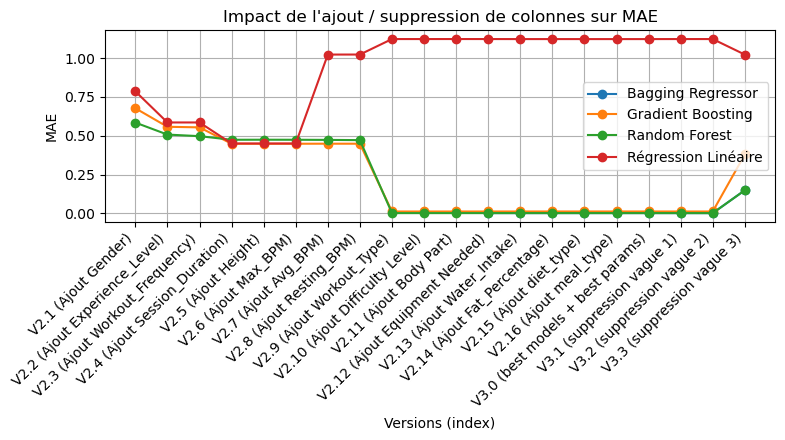

In [21]:
# === Focus sur une évolution de features/labels (ex. ajout de 'Gender') ===
if 'features' in df.columns:
    mask = df['features'].astype(str).str.contains('Gender', case=False, na=False)
    sub = df[mask]
    if not sub.empty and sub['MAE'].notna().any():
        plot_metric(sub, metric='MAE', group_col='model' if 'model' in sub.columns else None,
                    title="Impact de l'ajout / suppression de colonnes sur MAE",
                    savepath=Path(FIG_DIR / 'impact_gender_MAE.png'))

## 10 derniers résultats

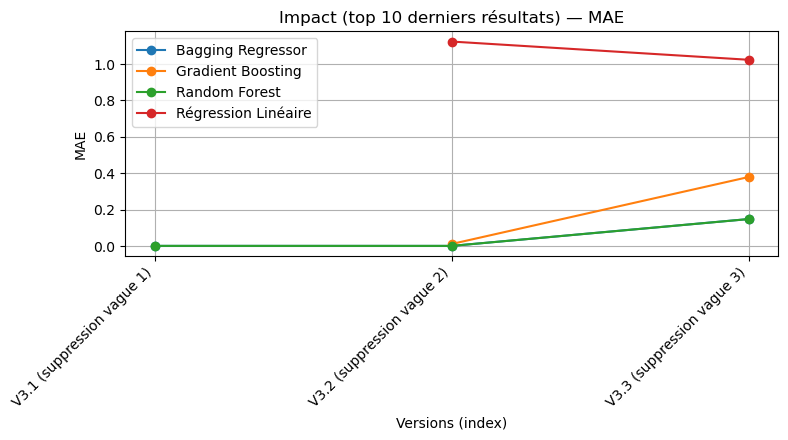

In [22]:
# Forçage du tri par l’index ou par colonne si dispo
sub_sorted = sub.sort_index()

# On prend les 10 derniers
sub_last10 = sub_sorted.tail(10)

if not sub_last10.empty:
    plot_metric(
        sub_last10,
        metric='MAE',
        group_col='model' if 'model' in sub_last10.columns else None,
        title="Impact (top 10 derniers résultats) — MAE",
        savepath=Path(FIG_DIR / 'impact_last10_MAE.png')
    )
